In [ ]:
import pandas as pd

titanic_path="/content/Titanic-Dataset.csv"
df=pd.read_csv(titanic_path)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
print("Unique values per column:")
df.nunique()

Unique values per column:


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
# Missing values per column
# 70% এর মত missng value থাকলে সেই feature টা drop করে দেয়াই ভালো
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


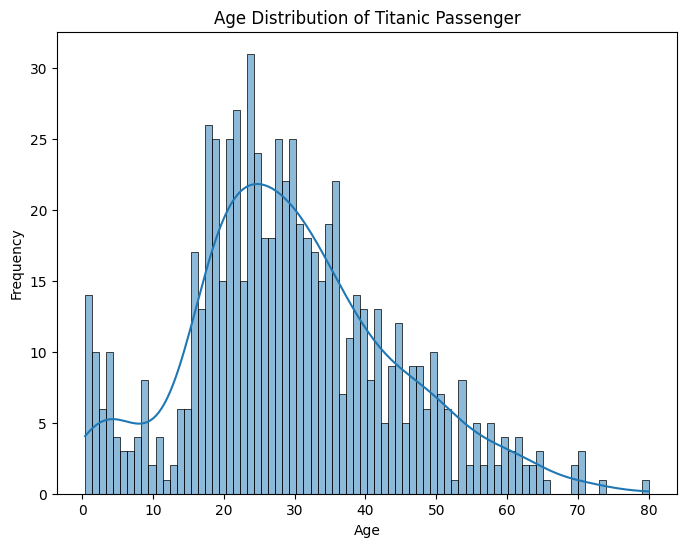

In [ ]:
# Distribution of Age

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df["Age"],kde=True, bins=80)
plt.title("Age Distribution of Titanic Passenger")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


# kde=True করে দিলে ওই লাইন টা দেখাবে, bins=40 মানে 80 টা data নিচ্ছে
# we will use Median as the feature values are right skewed

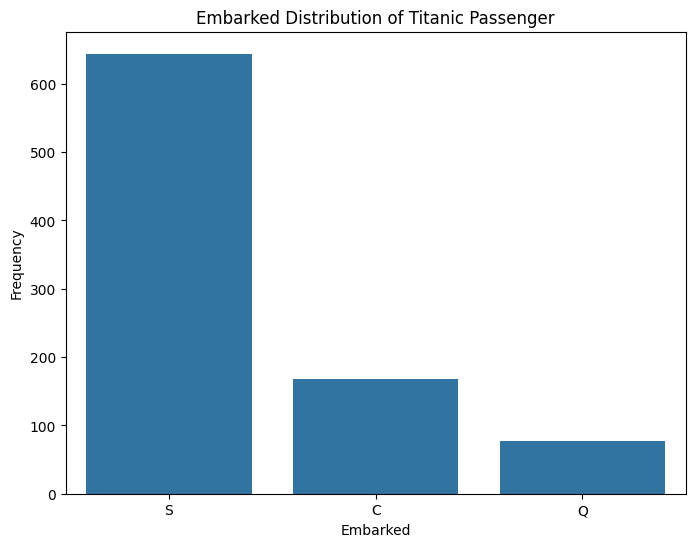

In [ ]:
# Distribution of Embarked

plt.figure(figsize=(8,6))
sns.countplot(data=df,x="Embarked")
plt.title("Embarked Distribution of Titanic Passenger")
plt.xlabel("Embarked")
plt.ylabel("Frequency")
plt.show()

# class টা fully imbalance , তাই এটার missing vlue Mode দিয়ে handle করতে হবে

# Handle Missing Values

In [ ]:
# Handle numeric missing valuues: Age
age_median=df["Age"].median()
df["Age"]=df["Age"].fillna(age_median)

# Handle categorical missing values: Embarked
embarked_mode=df["Embarked"].mode()[0]
df['Embarked']=df['Embarked'].fillna(embarked_mode)

# Drop Cabin (Too many missing values)
df=df.drop(columns=["Cabin"])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
